In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from bidict import bidict
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [8]:
ENCODER = bidict({
    'ha': 0,
    'ba': 1, 
    'ga': 2
})

In [9]:
labels = np.load("../data_cc2/labels.npy")
labels = labels - 1
labels.shape

(407,)

In [10]:
imgs = np.load("../data_cc2/imgs.npy").astype("float32") / 255

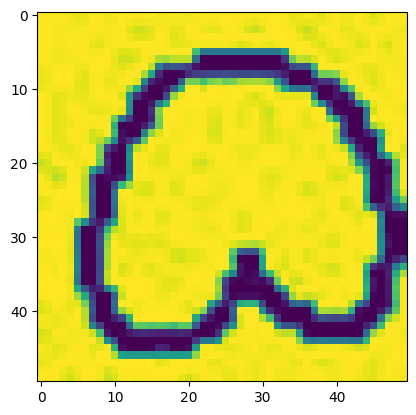

In [11]:
# check out one of the images
plt.figure()
plt.imshow(imgs[0])
plt.grid(False)
plt.show()

In [12]:
if imgs.ndim == 3:
    imgs = np.expand_dims(imgs, -1)

In [13]:
imgs_train, imgs_test, labels_train, labels_test = train_test_split(
    imgs, labels, test_size=0.20, stratify=labels, random_state=42
)

In [14]:
print(imgs_train.shape)
print(labels_train.shape)

print(labels_train.min())
print(labels_train.max())

(325, 50, 50, 1)
(325,)
0
2


In [15]:
def add_noise(img):
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.05, dtype=tf.float32)
    return tf.clip_by_value(img + noise, 0.0, 1.0)

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
)
datagen.fit(imgs_train)

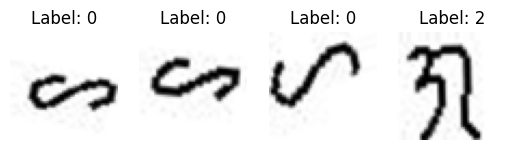

In [16]:
for x_batch, y_batch in datagen.flow(imgs_train, labels_train, batch_size=4):
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.imshow(x_batch[i].squeeze(), cmap='gray')
        plt.title(f"Label: {y_batch[i]}")
        plt.axis('off')
    plt.show()
    break

In [17]:
from tensorflow.keras import regularizers

batch_size = 8
epochs = 30

model = keras.Sequential([
    keras.Input(shape=(50, 50, 1)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
# checkpoint = ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)

optimizer = keras.optimizers.Adam()

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

In [19]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_train),
    y=labels_train
)

class_weight_dict = dict(enumerate(class_weights))

model.fit(
    datagen.flow(imgs_train, labels_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(imgs_test, labels_test),
    callbacks=[early_stopping, lr_scheduler],
    class_weight=class_weight_dict
)

Epoch 1/30


C:\Users\ASUS\Desktop\baybayin-ml\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7739 - loss: 0.6362 - val_accuracy: 0.3659 - val_loss: 1.2920 - learning_rate: 0.0010
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9423 - loss: 0.2816 - val_accuracy: 0.6098 - val_loss: 1.2510 - learning_rate: 0.0010
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9863 - loss: 0.1887 - val_accuracy: 0.3537 - val_loss: 1.2073 - learning_rate: 0.0010
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9664 - loss: 0.2159 - val_accuracy: 0.3537 - val_loss: 1.2056 - learning_rate: 0.0010
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9951 - loss: 0.1627 - val_accuracy: 0.3537 - val_loss: 1.1852 - learning_rate: 0.0010
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9812 - loss: 0.1748 - val_accuracy: 0.3537 - val_loss: 1.2334 - learning_rate: 0.0010
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9921 - loss: 0.1472 - val_accuracy: 0.35

In [20]:
print(labels_train[:5])  # should be like: [0, 2, 1, 0, 1]
print(np.unique(labels_train))  # should show: [0 1 2]

[1 1 0 1 1]
[0 1 2]


32 128-3-2 256-3-2 .9102
32 256-3-2 128-3-2 .9077
32 128-3-2 256-3-2 512-3-2 .9127
32 128-1-2 256-3-2 512-5-2 .9327
32 128-5-2 256-5-2 512-5-2 .9626

In [21]:
model.evaluate(imgs_test, labels_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0727


[0.0727207139134407, 1.0]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


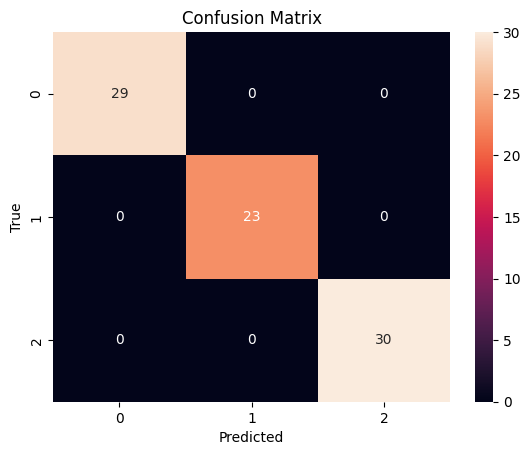

In [22]:
y_pred = model.predict(imgs_test)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(labels_test, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=ENCODER.inverse, yticklabels=ENCODER.inverse)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [23]:
wrong = np.where(y_pred_labels != labels_test)[0]
for i in wrong[:5]:
    plt.imshow(imgs_test[i].squeeze(), cmap='gray')
    print(f"True: {ENCODER.inverse[labels_test[i]]}, Pred: {ENCODER.inverse[y_pred_labels[i]]}")
    plt.show()

In [24]:
import numpy as np

sample_imgs = imgs_test[:5]
sample_labels = labels_test[:5]

preds = model.predict(sample_imgs)
predicted_classes = np.argmax(preds, axis=1)

print("Predicted:", predicted_classes)
print("Actual:   ", sample_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted: [2 2 0 1 1]
Actual:    [2 2 0 1 1]


In [25]:
import numpy as np
from collections import Counter

print("Train:", Counter(labels_train))
print("Test:", Counter(labels_test))

Train: Counter({np.int64(0): 117, np.int64(2): 117, np.int64(1): 91})
Test: Counter({np.int64(2): 30, np.int64(0): 29, np.int64(1): 23})


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


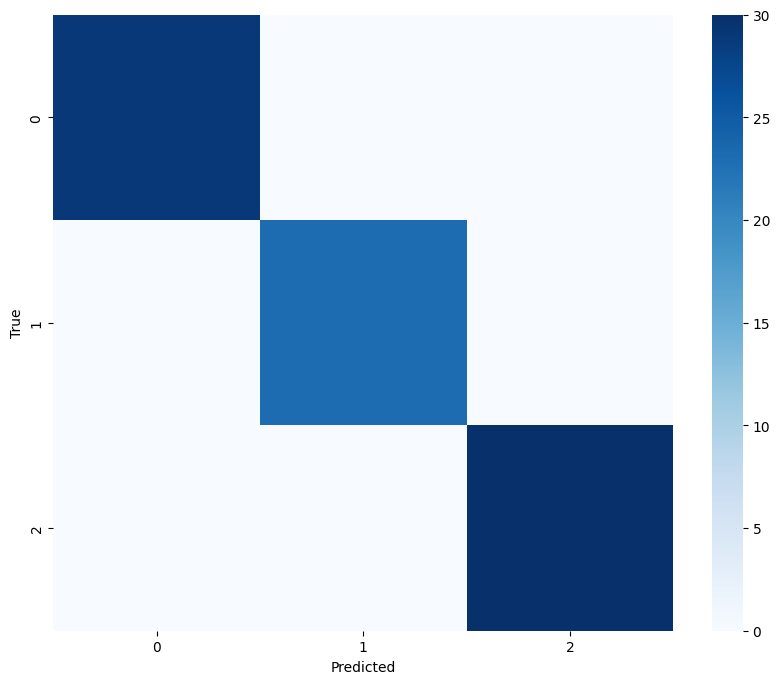

In [26]:
y_pred = model.predict(imgs_test).argmax(axis=1)
cm = confusion_matrix(labels_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 24, 24, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 22, 22, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 11, 11, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7744)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         495,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,544,843 (5.89 MB)

 Trainable params: 514,883 (1.96 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 1,029,768 (3.93 MB)

In [28]:
model.save("model_cc2_2.keras")